<a href="https://colab.research.google.com/github/Rohan-1103/Data-Science/blob/main/DL/transfer_learning_feature_extraction(data_augmentation)_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kagglehub

In [2]:
import kagglehub
import os
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten
from keras.applications.vgg16 import VGG16

In [3]:
base_path = kagglehub.dataset_download("tongpython/cat-and-dog")

# Correct nested paths
train_dir = base_path + "/training_set/training_set"
test_dir = base_path + "/test_set/test_set"

print("Train folders:", os.listdir(train_dir))
print("Test folders:", os.listdir(test_dir))

Using Colab cache for faster access to the 'cat-and-dog' dataset.
Train folders: ['dogs', 'cats']
Test folders: ['dogs', 'cats']


In [4]:
conv_base = VGG16(
    weights='imagenet',
    include_top = False,
    input_shape=(150,150,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [6]:
conv_base.trainable = False

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img

### Data Augmentation

In [9]:
batch_size = 32

train_datagen = ImageDataGenerator(
        rescale=1./255,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(150, 150),
        batch_size=batch_size,
        class_mode='binary')

validation_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(150, 150),
        batch_size=batch_size,
        class_mode='binary')

Found 8005 images belonging to 2 classes.
Found 2023 images belonging to 2 classes.


In [10]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [12]:
history = model.fit(
        train_generator,
        epochs=10,
        validation_data=validation_generator)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 124s 459ms/step - accuracy: 0.8465 - loss: 0.3664 - val_accuracy: 0.8606 - val_loss: 0.3113
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 69s 274ms/step - accuracy: 0.8942 - loss: 0.2465 - val_accuracy: 0.8932 - val_loss: 0.2664
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 65s 259ms/step - accuracy: 0.9003 - loss: 0.2331 - val_accuracy: 0.8972 - val_loss: 0.2648
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 66s 262ms/step - accuracy: 0.9119 - loss: 0.2099 - val_accuracy: 0.9076 - val_loss: 0.2198
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 66s 262ms/step - accuracy: 0.9169 - loss: 0.1978 - val_accuracy: 0.9041 - val_loss: 0.2388
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 66s 265ms/step - accuracy: 0.9112 - loss: 0.2056 - val_accuracy: 0.9066 - val_loss: 0.2353
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 82s 264ms/step - accuracy: 0.9162 - loss: 0.1959 - val_accuracy: 0.8883 - val_loss: 0.2854
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 67s 267ms/step - accuracy: 0.9257 - loss: 

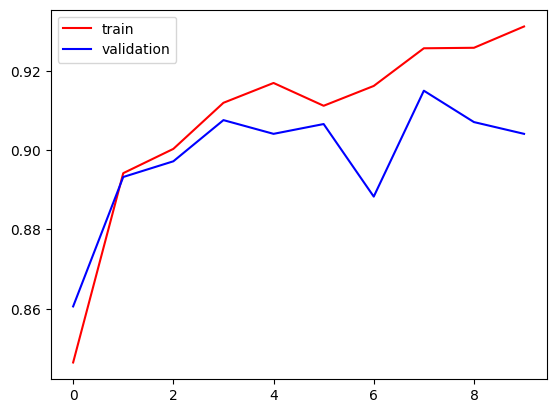

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

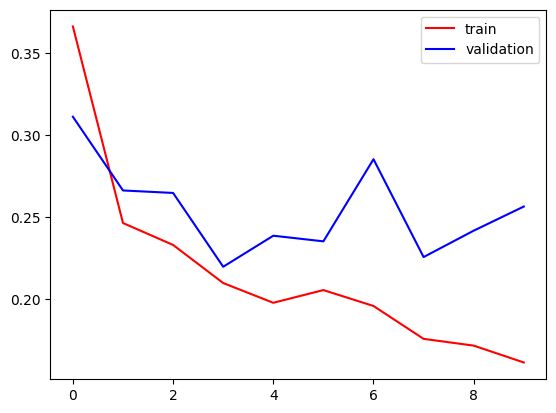

In [14]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()